0. Setup & Imports

In [2]:
import torch, numpy
print(torch.__version__, torch.version.cuda)
print(numpy.__version__)

2.5.1 11.8
1.26.4


In [3]:
# Cell 0: Environment setup & imports

!pip install torch torchvision matplotlib seaborn tqdm opencv-python -q

import os
import copy
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda



1. Data loading, exploration, preprocessing, augmentation

In [4]:
# Cell 1: Define transforms (normalization + augmentation)

# CIFAR-10 mean/std (can also compute dynamically)
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomCrop(32, padding=4),
    # optional color jitter
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

data_root = "./data"

train_dataset_full = torchvision.datasets.CIFAR10(
    root=data_root, train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root=data_root, train=False, download=True, transform=test_transform
)

class_names = train_dataset_full.classes
num_classes = len(class_names)
print("Classes:", class_names)
len(train_dataset_full), len(test_dataset)


Files already downloaded and verified
Files already downloaded and verified
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


(50000, 10000)

In [5]:
# Cell 2: Train/validation split and dataloaders

batch_size = 64

val_ratio = 0.1
val_size = int(len(train_dataset_full) * val_ratio)
train_size = len(train_dataset_full) - val_size

train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

# IMPORTANT: validation should NOT use augmentation, use test_transform
val_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

len(train_loader), len(val_loader), len(test_loader)


(704, 79, 157)

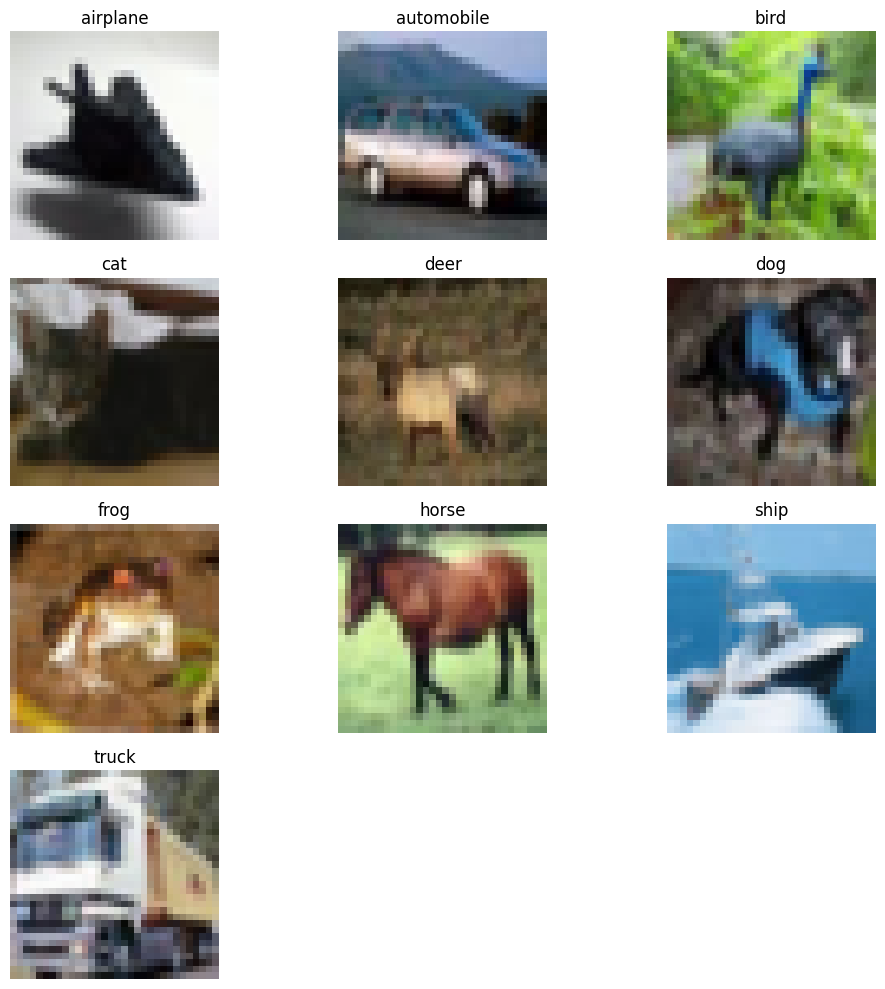

In [6]:
# Cell 3: Visualize 10x10 grid with one sample per class (if possible)

def imshow(img, mean, std):
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")

# collect 1 image per class
samples_per_class = {c: None for c in class_names}
for img, label in train_dataset_full:
    class_name = class_names[label]
    if samples_per_class[class_name] is None:
        samples_per_class[class_name] = img
    if all(v is not None for v in samples_per_class.values()):
        break

plt.figure(figsize=(10, 10))
for i, (cls, img) in enumerate(samples_per_class.items()):
    plt.subplot(4, 3, i + 1)
    imshow(img.cpu(), cifar10_mean, cifar10_std)
    plt.title(cls)
plt.tight_layout()
plt.show()


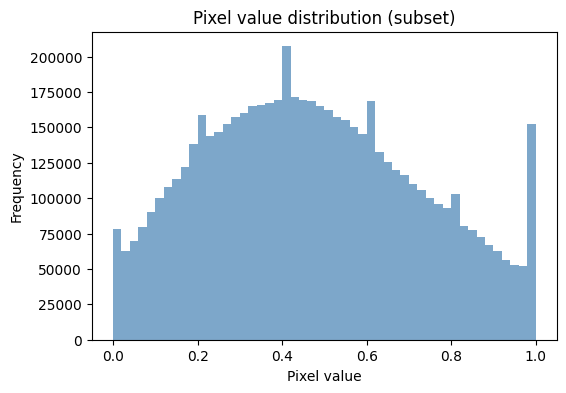

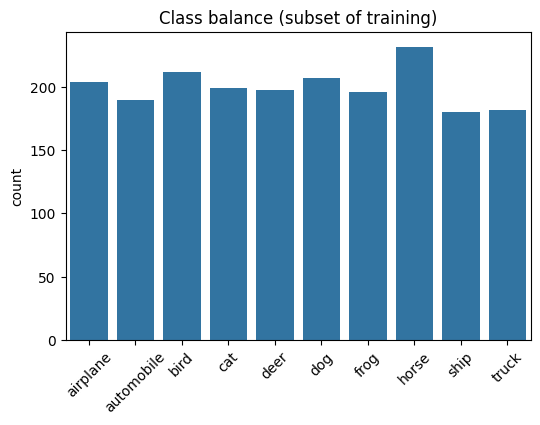

In [7]:
# Cell 4: Pixel value distribution & class balance

# sample a subset for histogram
subset_indices = np.random.choice(len(train_dataset_full), size=2000, replace=False)
pixels = []
labels = []

for idx in subset_indices:
    img, label = train_dataset_full[idx]
    # invert normalization for analysis
    img_np = img.numpy()
    for c in range(3):
        img_np[c] = img_np[c] * cifar10_std[c] + cifar10_mean[c]
    pixels.append(img_np.flatten())
    labels.append(label)

pixels = np.concatenate(pixels)
labels = np.array(labels)

plt.figure(figsize=(6, 4))
plt.hist(pixels, bins=50, color="steelblue", alpha=0.7)
plt.title("Pixel value distribution (subset)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x=labels)
plt.xticks(ticks=range(num_classes), labels=class_names, rotation=45)
plt.title("Class balance (subset of training)")
plt.show()


2. Baseline CNN model

In [8]:
# Cell 5: Baseline CNN architecture (as per assignment)

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Conv2D(32, 3x3)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                         # MaxPool(2x2)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),# Conv2D(64, 3x3)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                         # MaxPool(2x2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),                 # assuming 32x32 -> 8x8
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)                 # output logits
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline_model = BaselineCNN(num_classes=num_classes).to(device)
baseline_model


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [9]:
# Cell 6: Model summary & parameter count for baseline

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(baseline_model)
print("Total trainable parameters:", count_parameters(baseline_model))


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total trainable parameters: 545098


In [10]:
def visualize_feature_maps(model, data_loader, num_maps=8):
    model.eval()
    images, _ = next(iter(data_loader))
    images = images.to(device)

    activation = {}

    def hook_fn(module, input, output):
        activation["fmap"] = output.detach()

    handle = model.features[0].register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(images[0:1])   # forward pass

    fmap = activation["fmap"].cpu()
    handle.remove()

    plt.figure(figsize=(12, 4))
    for i in range(min(num_maps, fmap.shape[1])):
        plt.subplot(2, num_maps // 2, i + 1)
        plt.imshow(fmap[0, i].numpy(), cmap="gray")
        plt.axis("off")

    plt.suptitle("Baseline CNN - Feature maps from first conv layer")
    plt.tight_layout()
    plt.show()

3. Advanced CNN (example: mini VGG with BatchNorm)

In [11]:
# Cell 8: Advanced CNN - Mini VGGNet with BatchNorm

class MiniVGG(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

advanced_model = MiniVGG(num_classes=num_classes).to(device)
print(advanced_model)
print("Advanced model parameters:", count_parameters(advanced_model))


MiniVGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128,

4. Training utilities (common for both models)

In [12]:
# Cell 9: Training & evaluation utilities

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        running_correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            running_correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


In [13]:
# Cell 10: Generic training loop with LR scheduler, early stopping, checkpointing

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    num_epochs=50,
    patience=15,
    model_name="model"
):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    patience_counter = 0

    checkpoint_dir = "./checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)
    best_model_path = os.path.join(checkpoint_dir, f"best_{model_name}.pth")

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if scheduler is not None:
            # Step on validation loss if ReduceLROnPlateau, else epoch-wise
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
        )

        # Early stopping & checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, best_model_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    total_time = time.time() - start_time
    print(f"Training complete in {total_time/60:.2f} minutes. Best val acc: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)

    # save history
    history_dir = "./history"
    os.makedirs(history_dir, exist_ok=True)
    hist_path = os.path.join(history_dir, f"{model_name}_history.json")
    with open(hist_path, "w") as f:
        json.dump(history, f)

    return model, history, best_model_path


5. Train baseline model

In [14]:
# Cell 11: Train baseline CNN

baseline_model = BaselineCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    baseline_model.parameters(),
    lr=0.001,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

baseline_model, baseline_history, baseline_ckpt = train_model(
    baseline_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    num_epochs=80,   # adjust 50–100
    patience=15,
    model_name="baseline_cnn"
)


Epoch [1/80] Train Loss: 2.0093 Acc: 0.2746 | Val Loss: 1.7428 Acc: 0.3882
Epoch [2/80] Train Loss: 1.6703 Acc: 0.3991 | Val Loss: 1.5033 Acc: 0.4606
Epoch [3/80] Train Loss: 1.5053 Acc: 0.4588 | Val Loss: 1.3904 Acc: 0.5070
Epoch [4/80] Train Loss: 1.4116 Acc: 0.4904 | Val Loss: 1.3087 Acc: 0.5230
Epoch [5/80] Train Loss: 1.3369 Acc: 0.5202 | Val Loss: 1.2493 Acc: 0.5484
Epoch [6/80] Train Loss: 1.2741 Acc: 0.5438 | Val Loss: 1.1928 Acc: 0.5722
Epoch [7/80] Train Loss: 1.2234 Acc: 0.5637 | Val Loss: 1.1498 Acc: 0.5788
Epoch [8/80] Train Loss: 1.1772 Acc: 0.5790 | Val Loss: 1.0993 Acc: 0.6034
Epoch [9/80] Train Loss: 1.1314 Acc: 0.5971 | Val Loss: 1.1070 Acc: 0.5994
Epoch [10/80] Train Loss: 1.0981 Acc: 0.6114 | Val Loss: 1.0412 Acc: 0.6202
Epoch [11/80] Train Loss: 1.0574 Acc: 0.6264 | Val Loss: 1.0178 Acc: 0.6344
Epoch [12/80] Train Loss: 1.0257 Acc: 0.6381 | Val Loss: 0.9945 Acc: 0.6440
Epoch [13/80] Train Loss: 0.9966 Acc: 0.6486 | Val Loss: 0.9679 Acc: 0.6528
Epoch [14/80] Train L

6. Train advanced model

In [15]:
# Cell 12: Train advanced MiniVGG

advanced_model = MiniVGG(num_classes=num_classes).to(device)

criterion_adv = nn.CrossEntropyLoss()
optimizer_adv = torch.optim.Adam(
    advanced_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler_adv = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_adv,
    mode="min",
    factor=0.5,
    patience=5
)

advanced_model, advanced_history, advanced_ckpt = train_model(
    advanced_model,
    train_loader,
    val_loader,
    criterion_adv,
    optimizer_adv,
    scheduler=scheduler_adv,
    num_epochs=80,
    patience=15,
    model_name="mini_vgg"
)


Epoch [1/80] Train Loss: 1.5378 Acc: 0.4355 | Val Loss: 1.2080 Acc: 0.5626
Epoch [2/80] Train Loss: 1.1179 Acc: 0.6014 | Val Loss: 1.0506 Acc: 0.6292
Epoch [3/80] Train Loss: 0.9317 Acc: 0.6756 | Val Loss: 0.8557 Acc: 0.7018
Epoch [4/80] Train Loss: 0.7954 Acc: 0.7269 | Val Loss: 0.9571 Acc: 0.6940
Epoch [5/80] Train Loss: 0.7071 Acc: 0.7639 | Val Loss: 0.7083 Acc: 0.7612
Epoch [6/80] Train Loss: 0.6156 Acc: 0.7969 | Val Loss: 0.6209 Acc: 0.7890
Epoch [7/80] Train Loss: 0.5417 Acc: 0.8213 | Val Loss: 0.6062 Acc: 0.8000
Epoch [8/80] Train Loss: 0.4809 Acc: 0.8440 | Val Loss: 0.8279 Acc: 0.7518
Epoch [9/80] Train Loss: 0.4230 Acc: 0.8603 | Val Loss: 0.5234 Acc: 0.8278
Epoch [10/80] Train Loss: 0.3698 Acc: 0.8789 | Val Loss: 0.5783 Acc: 0.8202
Epoch [11/80] Train Loss: 0.3245 Acc: 0.8927 | Val Loss: 0.5149 Acc: 0.8416
Epoch [12/80] Train Loss: 0.2828 Acc: 0.9056 | Val Loss: 0.5626 Acc: 0.8256
Epoch [13/80] Train Loss: 0.2487 Acc: 0.9191 | Val Loss: 0.6818 Acc: 0.8150
Epoch [14/80] Train L

7. Plot training/validation curves

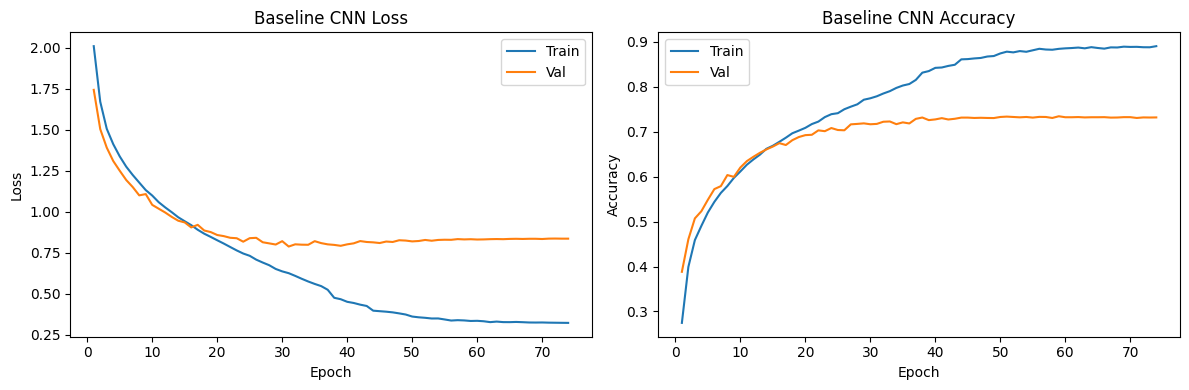

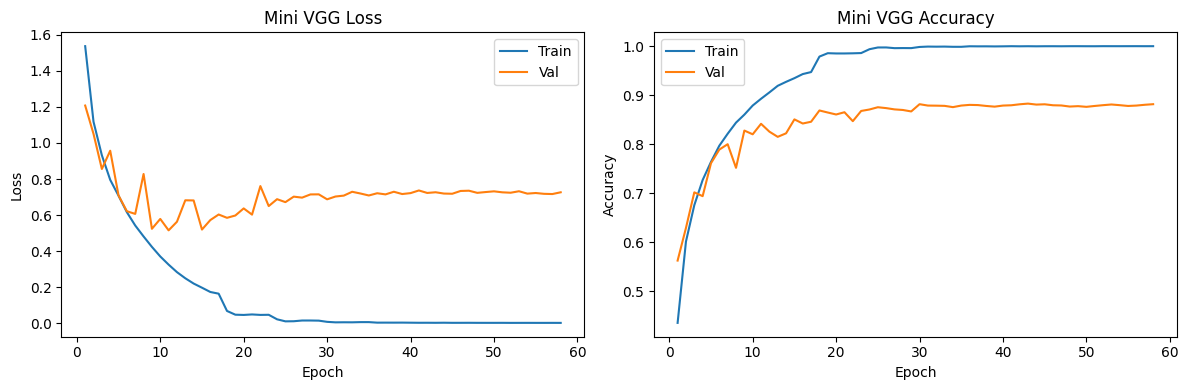

In [16]:
# Cell 13: Plot training & validation loss/accuracy curves for both models

def plot_history(history, title_prefix="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, title_prefix="Baseline CNN")
plot_history(advanced_history, title_prefix="Mini VGG")


8. Test set evaluation, confusion matrix, per-class accuracy, misclassified images

In [17]:
# Cell 14: Helper to evaluate on test set and collect predictions

def get_predictions(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Load best checkpoint before final test evaluation (optional, already loaded)
baseline_model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
advanced_model.load_state_dict(torch.load(advanced_ckpt, map_location=device))

test_loss_baseline, test_acc_baseline = evaluate(baseline_model, test_loader, criterion, device)
test_loss_adv, test_acc_adv = evaluate(advanced_model, test_loader, criterion_adv, device)

print(f"Baseline CNN - Test Loss: {test_loss_baseline:.4f}, Test Acc: {test_acc_baseline:.4f}")
print(f"Mini VGG     - Test Loss: {test_loss_adv:.4f}, Test Acc: {test_acc_adv:.4f}")


/tmp/ipykernel_43027/2750188832.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline_model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
/tmp/ipyk

Baseline CNN - Test Loss: 0.8398, Test Acc: 0.7392
Mini VGG     - Test Loss: 0.6957, Test Acc: 0.8844


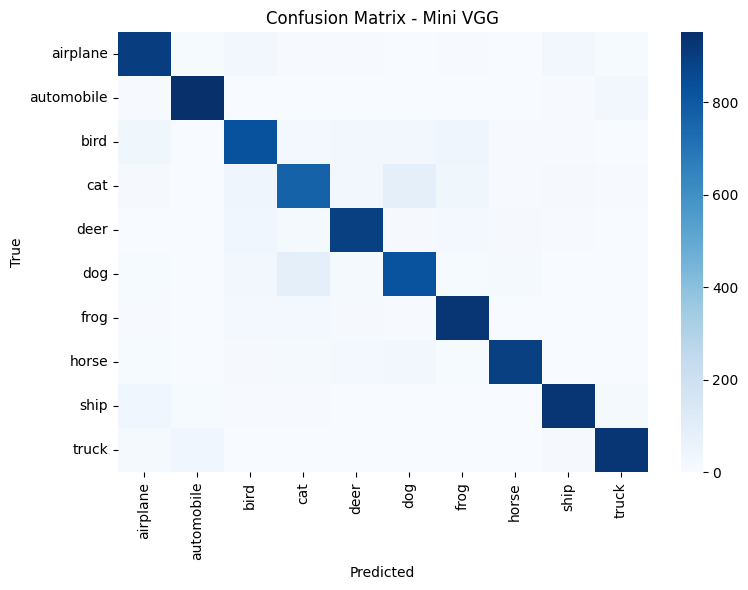

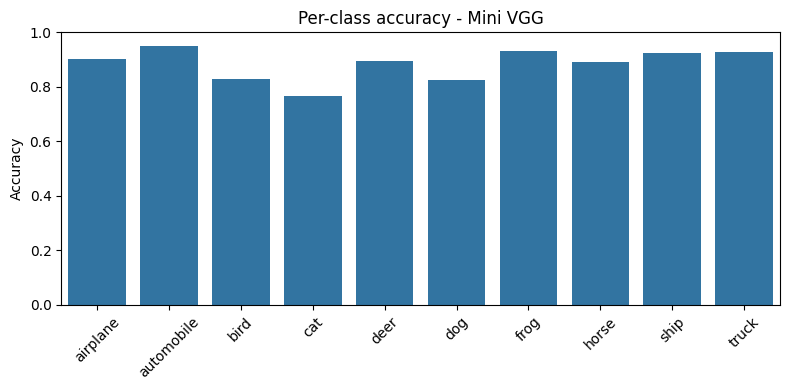

Per-class accuracies:
airplane: 0.902
automobile: 0.951
bird: 0.829
cat: 0.767
deer: 0.893
dog: 0.825
frog: 0.930
horse: 0.892
ship: 0.926
truck: 0.929


In [18]:
# Cell 15: Confusion matrix and per-class accuracy (advanced model as example)

y_true, y_pred, _ = get_predictions(advanced_model, test_loader, device)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Mini VGG")
plt.tight_layout()
plt.show()

# per-class accuracy
class_correct = cm.diagonal()
class_totals = cm.sum(axis=1)
per_class_acc = class_correct / class_totals

plt.figure(figsize=(8, 4))
sns.barplot(x=class_names, y=per_class_acc)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Per-class accuracy - Mini VGG")
plt.tight_layout()
plt.show()

print("Per-class accuracies:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls}: {acc:.3f}")


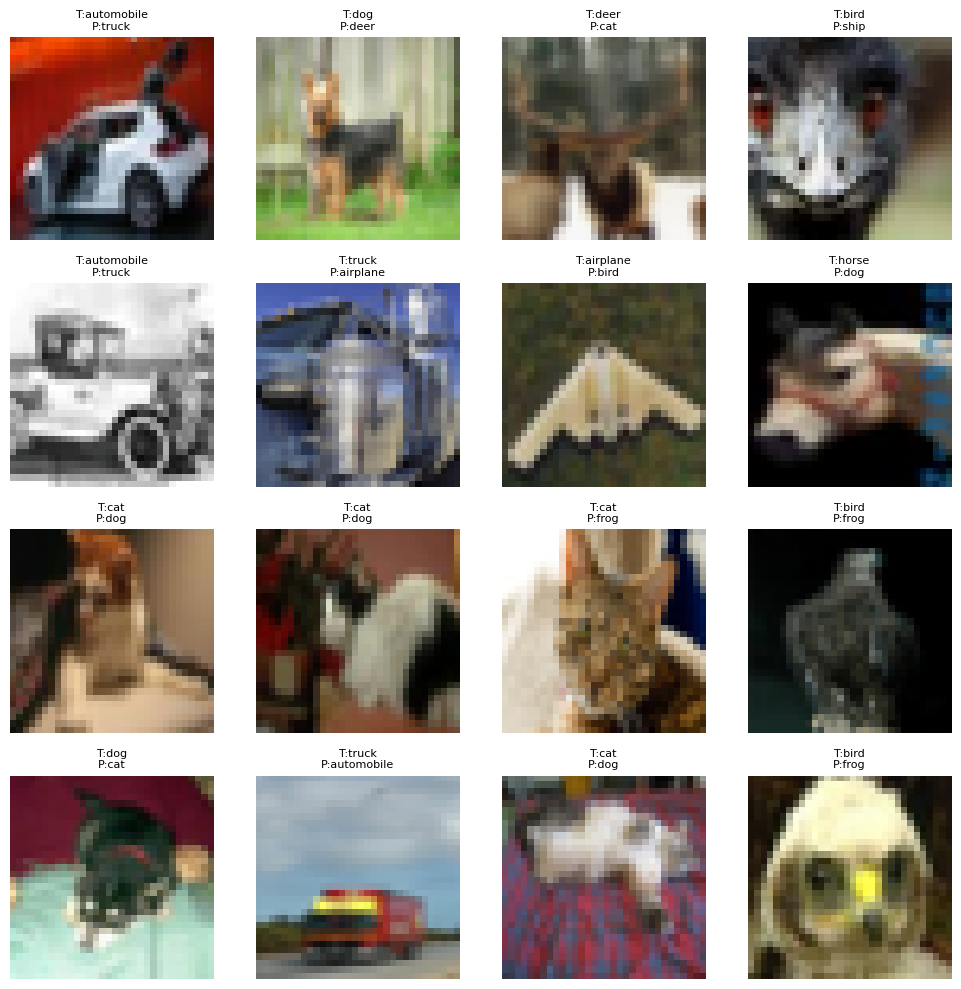

In [19]:
# Cell 16: Visualize misclassified images grid (advanced model)

def show_misclassified(model, loader, class_names, max_images=16):
    model.eval()
    images_list = []
    true_list = []
    pred_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device) 
            outputs = model(images)
            _, preds = outputs.max(1)

            mis_mask = preds != labels
            mis_images = images[mis_mask]
            mis_labels = labels[mis_mask]
            mis_preds = preds[mis_mask]

            for img, t, p in zip(mis_images, mis_labels, mis_preds):
                images_list.append(img.cpu())
                true_list.append(t.item())
                pred_list.append(p.item())
                if len(images_list) >= max_images:
                    break
            if len(images_list) >= max_images:
                break

    mean = torch.tensor(cifar10_mean).view(3, 1, 1)
    std = torch.tensor(cifar10_std).view(3, 1, 1)

    plt.figure(figsize=(10, 10))
    for i in range(len(images_list)):
        plt.subplot(4, 4, i + 1)
        img = images_list[i] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"T:{class_names[true_list[i]]}\nP:{class_names[pred_list[i]]}", fontsize=8)
    plt.tight_layout()
    plt.show()

show_misclassified(advanced_model, test_loader, class_names, max_images=16)


9. Filter visualization (first conv layer)

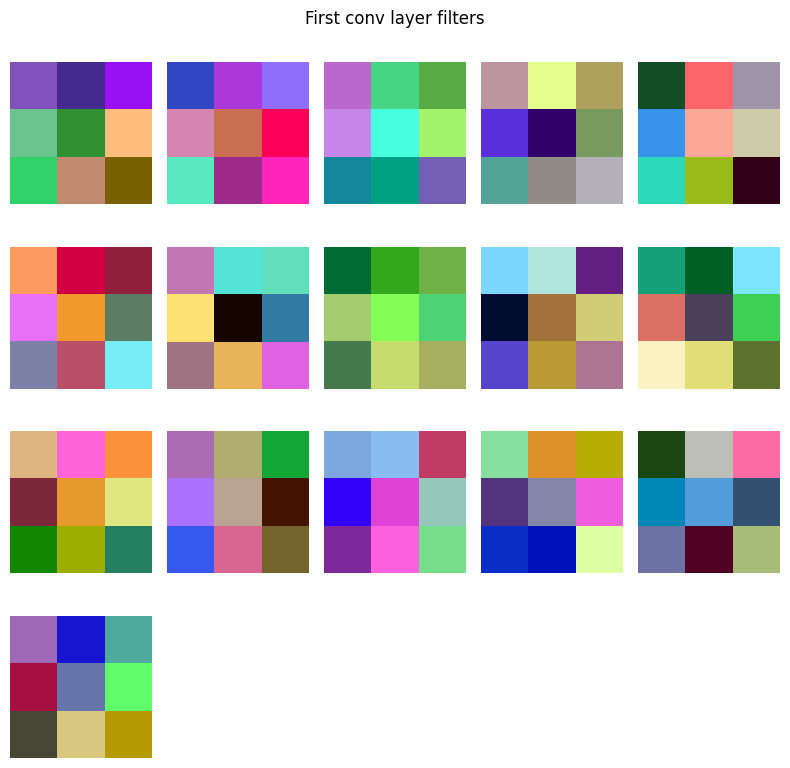

In [20]:
# Cell 17: Visualize learned filters (first conv layer) of advanced model

def visualize_filters(model, layer_name="features.0", num_filters=16):
    # get layer
    layer = dict(model.named_modules())[layer_name]
    weights = layer.weight.data.cpu()  # [out_channels, in_channels, k, k]

    n = min(num_filters, weights.shape[0])
    plt.figure(figsize=(8, 8))
    for i in range(n):
        w = weights[i]
        w_min, w_max = w.min(), w.max()
        w_norm = (w - w_min) / (w_max - w_min + 1e-5)
        w_np = w_norm.permute(1, 2, 0).numpy()
        plt.subplot(int(np.sqrt(n)), int(np.sqrt(n)) + 1, i + 1)
        plt.imshow(w_np)
        plt.axis("off")
    plt.suptitle("First conv layer filters")
    plt.tight_layout()
    plt.show()

visualize_filters(advanced_model, layer_name="features.0", num_filters=16)


10. GradCAM for interpretability

In [21]:
# Cell 18: Fixed GradCAM implementation

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.zero_grad()
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()
        elif isinstance(target_class, torch.Tensor):
            target_class = target_class.item()

        loss = output[0, target_class]
        loss.backward()

        grads = self.gradients[0]
        activations = self.activations[0]

        weights = grads.mean(dim=(1, 2))
        cam = torch.zeros(activations.shape[1:], device=activations.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = F.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.detach().cpu().numpy()

In [22]:
def show_gradcam_on_image(img_tensor, cam, mean, std, alpha=0.4):
    img = img_tensor.cpu() * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = heatmap.astype(np.float32) / 255.0
    heatmap = heatmap[..., ::-1]

    overlay = alpha * heatmap + (1 - alpha) * img
    overlay = np.clip(overlay, 0, 1)

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("GradCAM")

    plt.tight_layout()
    plt.show()

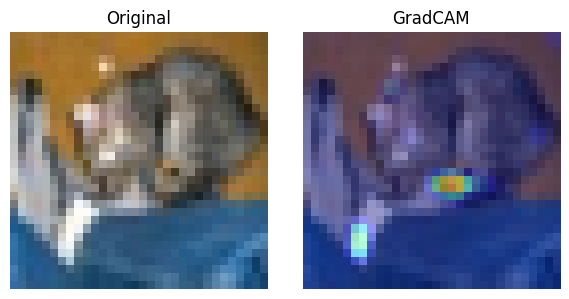

True label: cat


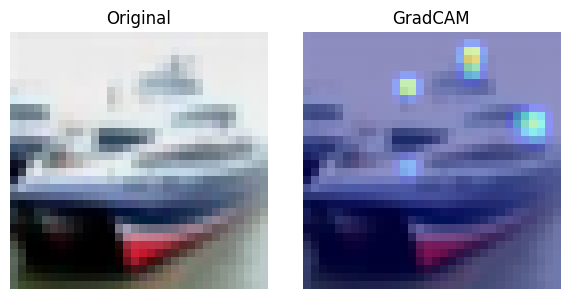

True label: ship


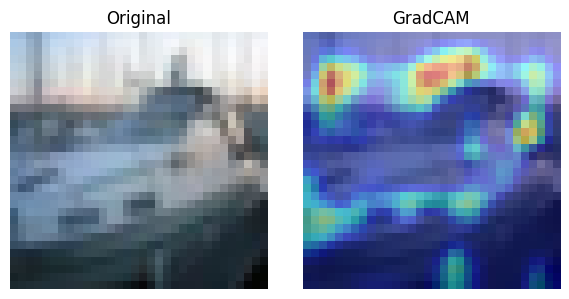

True label: ship


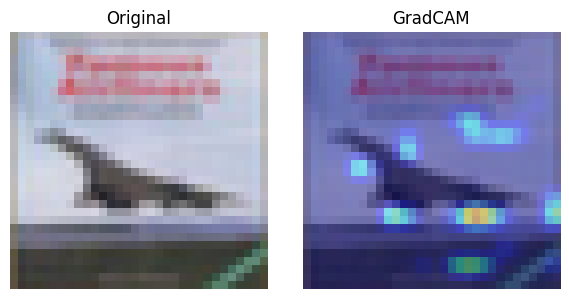

True label: airplane


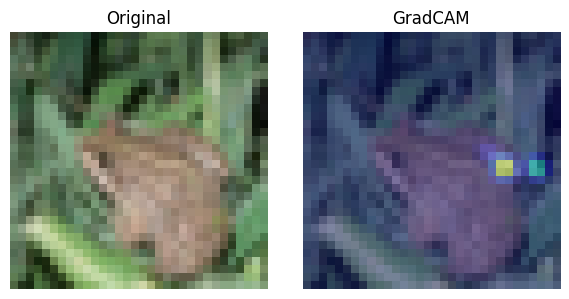

True label: frog


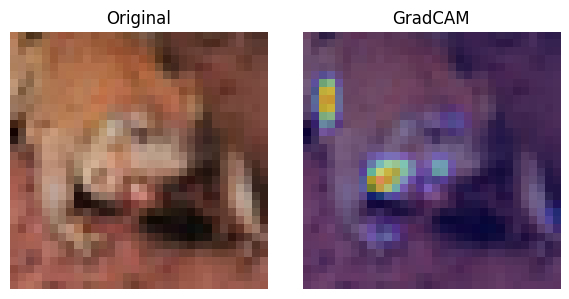

True label: frog


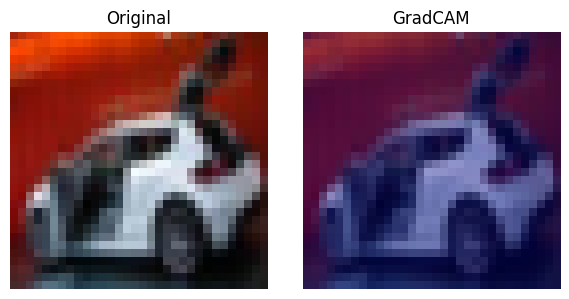

True label: automobile


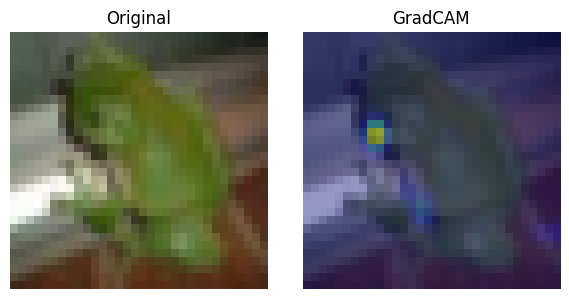

True label: frog


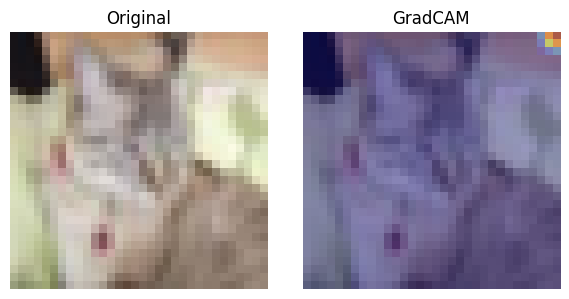

True label: cat


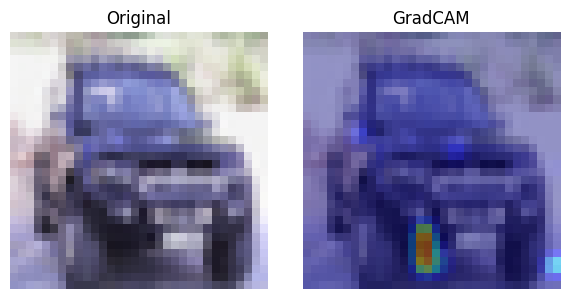

True label: automobile


In [23]:
# Cell 19: Generate GradCAM for 10 sample test images

import cv2

target_layer = advanced_model.features[10]
gradcam = GradCAM(advanced_model, target_layer)

mean_t = torch.tensor(cifar10_mean).view(3, 1, 1)
std_t = torch.tensor(cifar10_std).view(3, 1, 1)

count = 0
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    for i in range(images.size(0)):
        img = images[i:i+1]
        label = labels[i].item()

        cam = gradcam.generate(img)
        show_gradcam_on_image(images[i].cpu(), cam, mean_t, std_t)
        print(f"True label: {class_names[label]}")

        count += 1
        if count >= 10:
            break
    if count >= 10:
        break

11. Transfer learning (e.g., ResNet18)

In [24]:
# Cell 20: Transfer learning with ResNet18

resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

criterion_tl = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(resnet.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler_tl = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_tl, mode="min", factor=0.5, patience=5, verbose=True
)

resnet, resnet_history, resnet_ckpt = train_model(
    resnet,
    train_loader,
    val_loader,
    criterion_tl,
    optimizer_tl,
    scheduler=scheduler_tl,
    num_epochs=50,
    patience=10,
    model_name="resnet18_tl"
)

test_loss_res, test_acc_res = evaluate(resnet, test_loader, criterion_tl, device)
print(f"ResNet18 TL - Test Loss: {test_loss_res:.4f}, Test Acc: {test_acc_res:.4f}")


/home/glitchedpotato/miniconda3/envs/gpu_env/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] Train Loss: 0.9050 Acc: 0.6959 | Val Loss: 0.7207 Acc: 0.7522
Epoch [2/50] Train Loss: 0.5887 Acc: 0.8012 | Val Loss: 0.5936 Acc: 0.8064
Epoch [3/50] Train Loss: 0.4557 Acc: 0.8463 | Val Loss: 0.6289 Acc: 0.7908
Epoch [4/50] Train Loss: 0.3620 Acc: 0.8772 | Val Loss: 0.5915 Acc: 0.8108
Epoch [5/50] Train Loss: 0.2943 Acc: 0.8992 | Val Loss: 0.6205 Acc: 0.8012
Epoch [6/50] Train Loss: 0.2360 Acc: 0.9194 | Val Loss: 0.6507 Acc: 0.8074
Epoch [7/50] Train Loss: 0.1969 Acc: 0.9327 | Val Loss: 0.6745 Acc: 0.8016
Epoch [8/50] Train Loss: 0.1584 Acc: 0.9468 | Val Loss: 0.7053 Acc: 0.8082
Epoch [9/50] Train Loss: 0.1436 Acc: 0.9520 | Val Loss: 0.7143 Acc: 0.8068
Epoch [10/50] Train Loss: 0.1294 Acc: 0.9556 | Val Loss: 0.7762 Acc: 0.8026
Epoch [11/50] Train Loss: 0.0490 Acc: 0.9837 | Val Loss: 0.7493 Acc: 0.8236
Epoch [12/50] Train Loss: 0.0341 Acc: 0.9896 | Val Loss: 0.8001 Acc: 0.8224
Epoch [13/50] Train Loss: 0.0304 Acc: 0.9900 | Val Loss: 0.7820 Acc: 0.8274
Epoch [14/50] Train L

12. Simple ensemble of models

In [25]:
# Cell 21: Ensemble predictions of 3 models (baseline + advanced + ResNet)

def ensemble_predict(models, loader, device):
    for m in models:
        m.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            probs_sum = None
            for m in models:
                outputs = m(images)
                probs = F.softmax(outputs, dim=1)
                probs_sum = probs if probs_sum is None else probs_sum + probs
            probs_avg = probs_sum / len(models)
            _, preds = probs_avg.max(1)

            all_labels.extend(labels.numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    acc = (all_labels == all_preds).mean()
    return acc

ensemble_models = [baseline_model, advanced_model, resnet]
ensemble_acc = ensemble_predict(ensemble_models, test_loader, device)
print("Ensemble test accuracy:", ensemble_acc)


Ensemble test accuracy: 0.8783


13. Test-time augmentation (TTA) for one model

In [27]:
# Cell 22: Test-time augmentation for advanced model

import torchvision.transforms.functional as TF

def tta_predict(model, dataset, batch_size=64):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for idx in range(0, len(dataset), batch_size):
            batch_indices = list(range(idx, min(idx + batch_size, len(dataset))))

            for i in batch_indices:
                img, label = dataset[i]   # img is already a tensor
                label = label

                probs_sum = None

                # TTA 1: original
                img1 = img.unsqueeze(0).to(device)
                outputs1 = model(img1)
                probs1 = F.softmax(outputs1, dim=1)
                probs_sum = probs1

                # TTA 2: horizontal flip
                img2 = TF.hflip(img).unsqueeze(0).to(device)
                outputs2 = model(img2)
                probs2 = F.softmax(outputs2, dim=1)
                probs_sum += probs2

                # TTA 3: slight rotation is harder on tensors, so skip or use PIL if needed
                probs_avg = probs_sum / 2

                _, pred = probs_avg.max(1)
                all_labels.append(label)
                all_preds.append(pred.item())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    return (all_labels == all_preds).mean()

tta_acc = tta_predict(advanced_model, test_dataset, batch_size=64)
print("TTA accuracy (Mini VGG):", tta_acc)

TTA accuracy (Mini VGG): 0.8931


14. Save requirements and sample outputs

In [28]:
# Cell 23: Save requirements.txt (minimal)

reqs = [
    "torch",
    "torchvision",
    "matplotlib",
    "seaborn",
    "tqdm",
    "opencv-python",
    "scikit-learn"
]
with open("requirements.txt", "w") as f:
    f.write("\n".join(reqs))
print("requirements.txt written.")


requirements.txt written.


In [29]:
# Cell 24: Example of saving training history to CSV for one model

import pandas as pd

os.makedirs("logs", exist_ok=True)

baseline_df = pd.DataFrame(baseline_history)
baseline_df.to_csv("logs/baseline_history.csv", index=False)

adv_df = pd.DataFrame(advanced_history)
adv_df.to_csv("logs/advanced_history.csv", index=False)

res_df = pd.DataFrame(resnet_history)
res_df.to_csv("logs/resnet_history.csv", index=False)

print("Training histories saved to logs/*.csv")


Training histories saved to logs/*.csv
